<a href="https://colab.research.google.com/github/Razvan8458/Cat-or-Dog-classifier/blob/main/Cat-or-dog-classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, InputLayer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [3]:
# Get project files
!wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

!unzip cats_and_dogs.zip

PATH = 'cats_and_dogs'

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir = os.path.join(PATH, 'test')

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])
total_val = sum([len(files) for r, d, files in os.walk(validation_dir)])
total_test = len(os.listdir(test_dir))

# Variables for pre-processing and training.
batch_size = 128
epochs = 15
IMG_HEIGHT = 150
IMG_WIDTH = 150

Streaming output truncated to the last 5000 lines.
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.60.jpg  
  inflating: cats_and_dogs/train/dogs/dog.858.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.858.jpg  
  inflating: cats_and_dogs/train/dogs/dog.680.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.680.jpg  
  inflating: cats_and_dogs/train/dogs/dog.694.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.694.jpg  
  inflating: cats_and_dogs/train/dogs/dog.864.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.864.jpg  
  inflating: cats_and_dogs/train/dogs/dog.870.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.870.jpg  
  inflating: cats_and_dogs/train/dogs/dog.871.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.871.jpg  
  inflating: cats_and_dogs/train/dogs/dog.865.jpg  
  inflating: __MACOSX/cats_and_dogs/train/dogs/._dog.865.jpg  
  inflating: cats_and_dogs/train/dogs/dog.695.jpg  
  inflating: __MACOSX/cats_and

In [14]:
# 3
train_image_generator = ImageDataGenerator(rescale = 1./255)
validation_image_generator = ImageDataGenerator(rescale = 1./255)
test_image_generator = ImageDataGenerator(rescale = 1./255)

train_data_gen = train_image_generator.flow_from_directory(directory = train_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary')
val_data_gen = validation_image_generator.flow_from_directory(directory = validation_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary')
#!mkdir cats_and_dogs/test/images
#!mv cats_and_dogs/test/*.jpg cats_and_dogs/test/images
test_data_gen = test_image_generator.flow_from_directory(directory = test_dir, batch_size = batch_size, target_size = (IMG_HEIGHT, IMG_WIDTH), class_mode = 'binary', shuffle = False)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 50 images belonging to 1 classes.


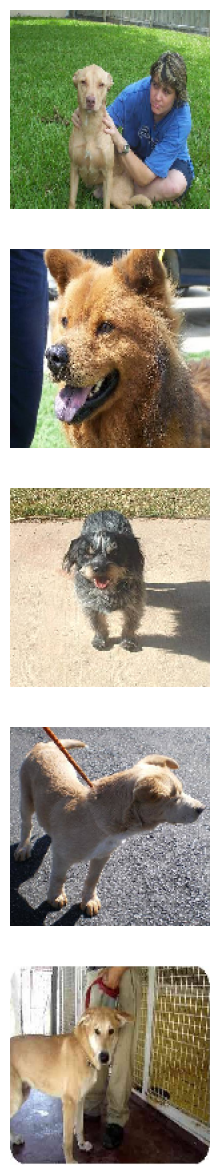

In [5]:
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])


In [6]:
# 5
train_image_generator = ImageDataGenerator(rescale = 1./255, rotation_range = 30, horizontal_flip = True, zoom_range = 0.2, shear_range = 0.05, brightness_range = [0.7, 1.3], channel_shift_range = 0.05)


Found 2000 images belonging to 2 classes.


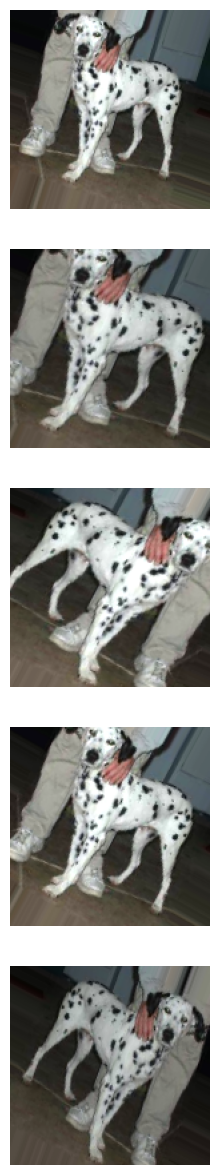

In [7]:
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [8]:
# 7
model = Sequential(

    [InputLayer(shape = [150, 150, 3]),
    Conv2D(filters = 16, kernel_size = 3, activation = 'relu'),
    Conv2D(filters = 16, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Conv2D(filters = 64, kernel_size = 3, activation = 'relu'),
    MaxPooling2D(pool_size = 2),
    Flatten(),
    Dense(256, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'sigmoid')]

)

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])






model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,228,721 (16.13 MB)

 Trainable params: 4,228,721 (16.13 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 8
history = model.fit(x = train_data_gen, steps_per_epoch = 16, epochs = epochs, validation_data = val_data_gen, validation_steps = 8)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 95s 6s/step - accuracy: 0.5286 - loss: 0.7648 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step - accuracy: 0.5145 - loss: 0.6916 - val_accuracy: 0.5440 - val_loss: 0.6886
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.5850 - loss: 0.6833 - val_accuracy: 0.5690 - val_loss: 0.6691
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 103s 7s/step - accuracy: 0.6097 - loss: 0.6670 - val_accuracy: 0.6330 - val_loss: 0.6603
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.6253 - loss: 0.6552 - val_accuracy: 0.6500 - val_loss: 0.6410
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.6407 - loss: 0.6453 - val_accuracy: 0.6120 - val_loss: 0.6472
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.6446 - loss: 0.6393 - val_accuracy: 0.6430 - val_loss: 0.6202
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.6780 - loss: 0.6091 - val_accuracy: 0.7030 - val_

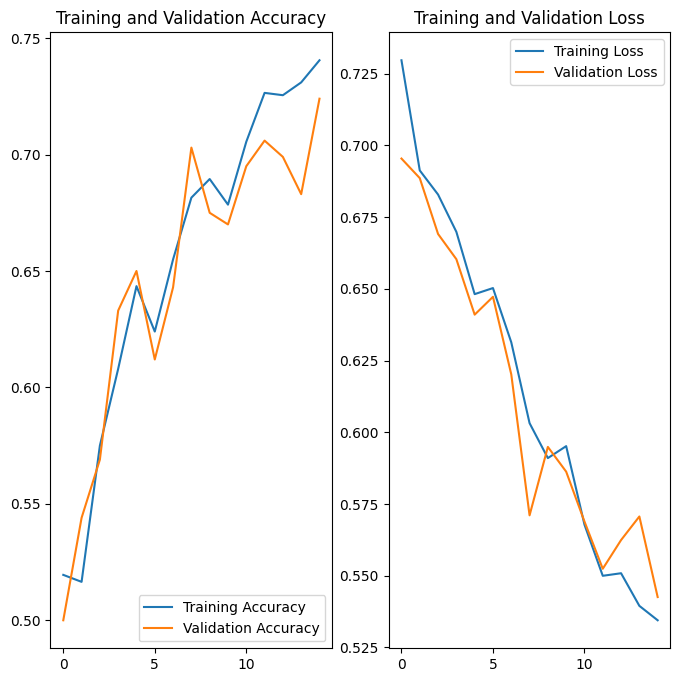

In [10]:
# 9
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [16]:
# 11
answers =  [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
            1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
            1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
            1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
            0, 0, 0, 0, 0, 0]

correct = 0
probabilities = model.predict(test_data_gen)
for probability, answer in zip(probabilities, answers):
  if round(probability[0]) == answer:
    correct +=1

percentage_identified = (correct / len(answers)) * 100

passed_challenge = percentage_identified >= 63

print(f"Your model correctly identified {round(percentage_identified, 2)}% of the images of cats and dogs.")

if passed_challenge:
  print("You passed the challenge!")
else:
  print("You haven't passed yet. Your model should identify at least 63% of the images. Keep trying. You will get it!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
Your model correctly identified 64.0% of the images of cats and dogs.
You passed the challenge!
